In [ ]:
pip install --upgrade keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 17.4 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.13.2
    Uninstalling keras-3.13.2:
      Successfully uninstalled keras-3.13.2


In [ ]:
pip install PyWavelets

**Import libraries and DATASET**

In [ ]:
# importing libraries
import numpy as np
import tensorflow as tf
import random as python_random
import pywt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from scipy.stats import skew, kurtosis, entropy
from skimage.io import imread

from skimage.transform import resize
from skimage.feature import hog
from skimage import exposure
import matplotlib.pyplot as plt
from skimage.feature import hog
import matplotlib.image as img
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from keras.metrics import Precision, Recall
from sklearn.decomposition import PCA
import seaborn as sns
from keras import models
import plotly.express as px
from matplotlib import offsetbox
from keras.layers import BatchNormalization
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Activation, Dropout, Flatten, Dense, SpatialDropout3D
from keras import backend as K
import keras
from keras import layers
from keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D, Conv2DTranspose, Flatten, Reshape
import random
from keras.models import Sequential, Model
from keras.layers import Flatten, Dense, Concatenate, Dot, Lambda, Input
import matplotlib.pyplot as plt
import cv2
import os
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense,GlobalAveragePooling2D
from tensorflow.keras.models import Model
from sklearn.metrics import precision_score
from sklearn.metrics import accuracy_score,precision_score
# np.random.seed(123)
# Set fixed random seeds
np.random.seed(42)
tf.random.set_seed(42)
from scipy import ndimage, datasets

# python_random.seed(123)
# tf.random.set_seed(1234)

In [ ]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [ ]:
X_valid = X_train[-6000:]
y_valid = y_train[-6000:]

X_train = X_train[0:54000]
y_train = y_train[0:54000]

In [ ]:
## Normalization
X_train = X_train.astype('float32') / 255
X_valid = X_valid.astype('float32') / 255
X_test = X_test.astype('float32') / 255

In [ ]:
print(X_train.shape)
print(y_train.shape)
print(X_valid.shape)
print(y_valid.shape)
print(X_test.shape)
print(y_test.shape)

(54000, 28, 28)
(54000,)
(6000, 28, 28)
(6000,)
(10000, 28, 28)
(10000,)


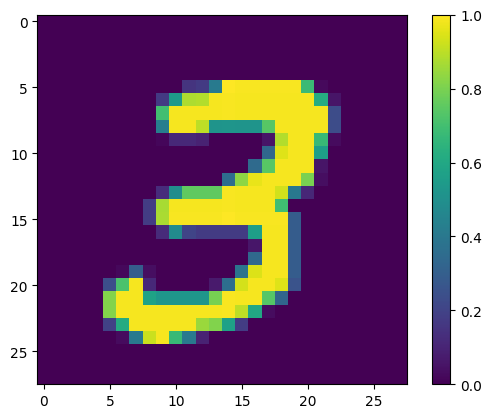

In [ ]:
plt.imshow(X_train[7])
plt.colorbar()
plt.show()

**Contrastive loss function and euclidean_distance**

In [ ]:
import keras
from keras import ops
def loss(margin=1):
    """Provides 'contrastive_loss' an enclosing scope with variable 'margin'.

    Arguments:
        margin: Integer, defines the baseline for distance for which pairs
                should be classified as dissimilar. - (default is 1).

    Returns:
        'contrastive_loss' function with data ('margin') attached.
    """

    # Contrastive loss = mean( (1-true_value) * square(prediction) +
    #                         true_value * square( max(margin-prediction, 0) ))
    def contrastive_loss(y_true, y_pred):
        """Calculates the contrastive loss.

        Arguments:
            y_true: List of labels, each label is of type float32.
            y_pred: List of predictions of same length as of y_true,
                    each label is of type float32.

        Returns:
            A tensor containing contrastive loss as floating point value.
        """

        square_pred = ops.square(y_pred)
        margin_square = ops.square(ops.maximum(margin - (y_pred), 0))
        return ops.mean((1 - y_true) * square_pred + (y_true) * margin_square)

    return contrastive_loss

In [ ]:
def euclidean_distance(vects):
    """Find the Euclidean distance between two vectors.

    Arguments:
        vects: List containing two tensors of same length.

    Returns:
        Tensor containing euclidean distance
        (as floating point value) between vectors.
    """

    x, y = vects
    sum_square = tf.math.reduce_sum(tf.math.square(x - y), axis=1, keepdims=True)
    return tf.math.sqrt(tf.math.maximum(sum_square, tf.keras.backend.epsilon()))

**WADeX method**

In [ ]:
import pywt
coef_train = pywt.wavedec2(X_train[0],'haar',level=1)
coef_test = pywt.wavedec2(X_test[0],'haar',level=1)   #'haar'=(14,14), 'bior1.3'=(16,16), 'bior3.1'=(15,15), 'sym8'=(21,21), db8=(21,21)
coef_valid = pywt.wavedec2(X_valid[0],'haar',level=1)

In [ ]:
WA_images_train = np.zeros((X_train.shape[0],14,14))
WA_images_test = np.zeros((X_test.shape[0],14,14))
WA_images_valid = np.zeros((X_valid.shape[0],14,14))

WH_images_train = np.zeros((X_train.shape[0],14,14))
WH_images_test = np.zeros((X_test.shape[0],14,14))
WH_images_valid = np.zeros((X_valid.shape[0],14,14))

WV_images_train = np.zeros((X_train.shape[0],14,14))
WV_images_test = np.zeros((X_test.shape[0],14,14))
WV_images_valid = np.zeros((X_valid.shape[0],14,14))

WD_images_train = np.zeros((X_train.shape[0],14,14))
WD_images_test = np.zeros((X_test.shape[0],14,14))
WD_images_valid = np.zeros((X_valid.shape[0],14,14))

In [ ]:
for indx in range(WA_images_train.shape[0]):
    coef_train = pywt.wavedec2(X_train[indx],'haar',level=1)
    WA_images_train[indx,:,:]= coef_train[0]

for indx in range(WH_images_train.shape[0]):
    coef_train = pywt.wavedec2(X_train[indx],'haar',level=1)
    WH_images_train[indx,:,:]= coef_train[1][0]

for indx in range(WV_images_train.shape[0]):
    coef_train = pywt.wavedec2(X_train[indx],'haar',level=1)
    WV_images_train[indx,:,:]= coef_train[1][1]

for indx in range(WD_images_train.shape[0]):
    coef_train = pywt.wavedec2(X_train[indx],'haar',level=1)
    WD_images_train[indx,:,:]= coef_train[1][2]

In [ ]:
for indx in range(WA_images_test.shape[0]):
    coef_test = pywt.wavedec2(X_test[indx],'haar',level=1)
    WA_images_test[indx,:,:]= coef_test[0]

for indx in range(WH_images_test.shape[0]):
    coef_test = pywt.wavedec2(X_test[indx],'haar',level=1)
    WH_images_test[indx,:,:]= coef_test[1][0]

for indx in range(WV_images_test.shape[0]):
    coef_test = pywt.wavedec2(X_test[indx],'haar',level=1)
    WV_images_test[indx,:,:]= coef_test[1][1]

for indx in range(WD_images_test.shape[0]):
    coef_test = pywt.wavedec2(X_test[indx],'haar',level=1)
    WD_images_test[indx,:,:]= coef_test[1][2]

In [ ]:
for indx in range(WA_images_valid.shape[0]):
    coef_valid = pywt.wavedec2(X_valid[indx],'haar',level=1)
    WA_images_valid[indx,:,:]= coef_valid[0]

for indx in range(WH_images_valid.shape[0]):
    coef_valid = pywt.wavedec2(X_valid[indx],'haar',level=1)
    WH_images_valid[indx,:,:]= coef_valid[1][0]

for indx in range(WV_images_valid.shape[0]):
    coef_valid = pywt.wavedec2(X_valid[indx],'haar',level=1)
    WV_images_valid[indx,:,:]= coef_valid[1][1]

for indx in range(WD_images_valid.shape[0]):
    coef_valid = pywt.wavedec2(X_valid[indx],'haar',level=1)
    WD_images_valid[indx,:,:]= coef_valid[1][2]

**Average Gradient and Weighted Wavelet**

In [ ]:
#train datatset
M=N=14

img_D =WD_images_train
grad_xD=cv2.Sobel(img_D,cv2.CV_64F,1,0,ksize=3)
grad_yD=cv2.Sobel(img_D,cv2.CV_64F,0,1,ksize=3)
grad_mag_D=np.hypot(grad_xD,grad_yD)
avg_grad_D=np.mean(grad_mag_D)/((M-1)*(N-1))
print(f'avg_grad_D(train): {avg_grad_D}')

img_V =WV_images_train
grad_xV=ndimage.prewitt(img_V, axis=0)
grad_yV=ndimage.prewitt(img_V, axis=1)
grad_mag_V=np.hypot(grad_xV,grad_yV)
avg_grad_V=np.mean(grad_mag_V)/((M-1)*(N-1))
print(f'avg_grad_V(train): {avg_grad_V}')

img_H = WH_images_train
grad_xH=ndimage.prewitt(img_H, axis=0)
grad_yH=ndimage.prewitt(img_H, axis=1)
grad_mag_H=np.hypot(grad_xH,grad_yH)
avg_grad_H=np.mean(grad_mag_H)/((M-1)*(N-1))
print(f'avg_grad_H(train): {avg_grad_H}')

avg_grad_D(train): 0.0012696349136291814
avg_grad_V(train): 0.0034644926019143344
avg_grad_H(train): 0.004723078253531419


In [ ]:
sum_grad_VHD=avg_grad_V+avg_grad_H+avg_grad_D
print(f'sum_grad_VHD(train):{sum_grad_VHD}')
# weight factors
lambda_V=1+(avg_grad_V/sum_grad_VHD)
print(f'lambda_V(train):{lambda_V}')

lambda_H=1+(avg_grad_H/sum_grad_VHD)
print(f'lambda_H(train):{lambda_H}')

lambda_D=1+(avg_grad_D/sum_grad_VHD)
print(f'lambda_D(train):{lambda_D}')

sum_grad_VHD(train):0.009457205769074935
lambda_V(train):1.3663336387628602
lambda_H(train):1.4994158284020727
lambda_D(train):1.1342505328350672


In [ ]:
lambda_Vn=lambda_V/4
lambda_Hn=lambda_H/4
lambda_Dn=lambda_D/4

print(f'lambda_Vn(train):{lambda_Vn}')
print(f'lambda_Hn(train):{lambda_Hn}')
print(f'lambda_Dn(train):{lambda_Dn}')

lambda_Vn(train):0.34158340969071505
lambda_Hn(train):0.37485395710051816
lambda_Dn(train):0.2835626332087668


In [ ]:
#test dataset

img_DD = WD_images_test
grad_xDD=cv2.Sobel(img_DD,cv2.CV_64F,1,0,ksize=3)
grad_yDD=cv2.Sobel(img_DD,cv2.CV_64F,0,1,ksize=3)
grad_mag_DD=np.hypot(grad_xDD,grad_yDD)
avg_grad_DD=np.mean(grad_mag_DD)/((M-1)*(N-1))
print(f'avg_grad_D(test): {avg_grad_DD}')

img_VV = WV_images_test
grad_xVV=ndimage.prewitt(img_VV, axis=0)
grad_yVV=ndimage.prewitt(img_VV, axis=1)
grad_mag_VV=np.hypot(grad_xVV,grad_yVV)
avg_grad_VV=np.mean(grad_mag_VV)/((M-1)*(N-1))
print(f'avg_grad_V(test): {avg_grad_VV}')

img_HH = WH_images_test
grad_xHH=ndimage.prewitt(img_HH, axis=0)
grad_yHH=ndimage.prewitt(img_HH, axis=1)
grad_mag_HH=np.hypot(grad_xHH,grad_yHH)
avg_grad_HH=np.mean(grad_mag_HH)/((M-1)*(N-1))
print(f'avg_grad_H(test): {avg_grad_HH}')

avg_grad_D(test): 0.0012585736920624827
avg_grad_V(test): 0.003500027688304687
avg_grad_H(test): 0.004722301921044895


In [ ]:
sum_grad_VVHHDD=avg_grad_VV+avg_grad_HH+avg_grad_DD
print(f'sum_grad_VHD(test):{sum_grad_VVHHDD}')
# weight factors
lambda_VV=1+(avg_grad_VV/sum_grad_VVHHDD)
print(f'lambda_V(test):{lambda_VV}')

lambda_HH=1+(avg_grad_HH/sum_grad_VVHHDD)
print(f'lambda_H(test):{lambda_HH}')

lambda_DD=1+(avg_grad_DD/sum_grad_VVHHDD)
print(f'lambda_D(test):{lambda_DD}')

sum_grad_VHD(test):0.009480903301412064
lambda_V(test):1.3691660569709008
lambda_H(test):1.4980856539631162
lambda_D(test):1.1327482890659832


In [ ]:
lambda_VVn=lambda_VV/4
lambda_HHn=lambda_HH/4
lambda_DDn=lambda_DD/4

print(f'lambda_Vn(test):{lambda_VVn}')
print(f'lambda_Hn(test):{lambda_HHn}')
print(f'lambda_Dn(test):{lambda_DDn}')

lambda_Vn(test):0.3422915142427252
lambda_Hn(test):0.37452141349077905
lambda_Dn(test):0.2831870722664958


In [ ]:
### valid dataset
img_DDD = WD_images_valid
grad_xDDD=cv2.Sobel(img_DDD,cv2.CV_64F,1,0,ksize=3)
grad_yDDD=cv2.Sobel(img_DDD,cv2.CV_64F,0,1,ksize=3)
grad_mag_DDD=np.hypot(grad_xDDD,grad_yDDD)          #np.sqrt(grad_xD**2+grad_yD**2)
avg_grad_DDD=np.mean(grad_mag_DDD)/((M-1)*(N-1))
print(f'avg_grad_D(val): {avg_grad_DDD}')


img_VVV = WV_images_valid
grad_xVVV=ndimage.prewitt(img_VVV, axis=0)
grad_yVVV=ndimage.prewitt(img_VVV, axis=1)
grad_mag_VVV=np.hypot(grad_xVVV,grad_yVVV)
avg_grad_VVV=np.mean(grad_mag_VVV)/((M-1)*(N-1))
print(f'avg_grad_V(val): {avg_grad_VVV}')

img_HHH = WH_images_valid
grad_xHHH=ndimage.prewitt(img_HHH, axis=0)
grad_yHHH=ndimage.prewitt(img_HHH, axis=1)
grad_mag_HHH=np.hypot(grad_xHHH,grad_yHHH)   #np.sqrt(grad_xH**2+grad_yH**2)
avg_grad_HHH=np.mean(grad_mag_HHH)/((M-1)*(N-1))
print(f'avg_grad_H(val): {avg_grad_HHH}')

avg_grad_D(val): 0.0012751629165265032
avg_grad_V(val): 0.00344014629443261
avg_grad_H(val): 0.004785295572968924


In [ ]:
sum_grad_VVVHHHDDD=avg_grad_VVV+avg_grad_HHH+avg_grad_DDD
print(f'sum_grad_VHD(val):{sum_grad_VVVHHHDDD}')
# weight factors
lambda_VVV=1+(avg_grad_VVV/sum_grad_VVVHHHDDD)
print(f'lambda_V(val):{lambda_VVV}')

lambda_HHH=1+(avg_grad_HHH/sum_grad_VVVHHHDDD)
print(f'lambda_H(val):{lambda_HHH}')

lambda_DDD=1+(avg_grad_DDD/sum_grad_VVVHHHDDD)
print(f'lambda_D(val):{lambda_DDD}')

sum_grad_VHD(val):0.009500604783928038
lambda_V(val):1.3620976109070686
lambda_H(val):1.5036832582557378
lambda_D(val):1.1342191308371934


In [ ]:
lambda_VVVn=lambda_VVV/4
lambda_HHHn=lambda_HHH/4
lambda_DDDn=lambda_DDD/4

print(f'lambda_Vn(val):{lambda_VVVn}')
print(f'lambda_Hn(val):{lambda_HHHn}')
print(f'lambda_Dn(val):{lambda_DDDn}')

lambda_Vn(val):0.34052440272676715
lambda_Hn(val):0.37592081456393445
lambda_Dn(val):0.28355478270929835


**Stack images**

In [ ]:
train_stack = np.zeros((X_train.shape[0],14,14,4))
for i in range (X_train.shape[0]):
   img=np.dstack((WA_images_train[i],lambda_Vn*WV_images_train[i],lambda_Hn*WH_images_train[i],lambda_Dn*WD_images_train[i]))
   train_stack[i,:,:]=img

In [ ]:
test_stack = np.zeros((X_test.shape[0],14,14,4))
for i in range (X_test.shape[0]):
   img=np.dstack((WA_images_test[i],lambda_VVn*WV_images_test[i],lambda_HHn*WH_images_test[i],lambda_DDn*WD_images_test[i] ))
   test_stack[i,:,:]=img

In [ ]:
val_stack = np.zeros((X_valid.shape[0],14,14,4))
for i in range (X_valid.shape[0]):
  img=np.dstack((WA_images_valid[i],lambda_VVVn*WV_images_valid[i],lambda_HHHn*WH_images_valid[i],lambda_DDDn*WD_images_valid[i] ))
  val_stack[i,:,:]=img

In [ ]:
X_train_s=train_stack
X_test_s=test_stack
X_val_s=val_stack

**Attention based to reconstruct image**

In [ ]:
# Initialize empty list to store single-channel images
single_channel_images_train = []

# Apply channel attention mechanism to each image
for image in X_train_s:
    # Compute channel attention weights
    attention_weights = np.mean(image, axis=(0, 1))

    # Normalize attention weights
    attention_weights = attention_weights / np.sum(attention_weights)
    # print(attention_weights)
    # Apply attention weights to channels
    single_channel_image_train = np.sum(image * attention_weights, axis=2)

    # Reshape to original image shape
    # single_channel_image_train = single_channel_image_train.reshape(28, 28)

    # Append single-channel image to list
    single_channel_images_train.append(single_channel_image_train)

# Convert list to numpy array
single_channel_images_train = np.array(single_channel_images_train)

In [ ]:
# Initialize empty list to store single-channel images
single_channel_images_test = []

# Apply channel attention mechanism to each image
for image in X_test_s:
    # Compute channel attention weights
    attention_weights = np.mean(image, axis=(0, 1))

    # Normalize attention weights
    attention_weights = attention_weights / np.sum(attention_weights)

    # Apply attention weights to channels
    single_channel_image_test = np.sum(image * attention_weights, axis=2)

    # Reshape to original image shape
    # single_channel_image_train = single_channel_image_train.reshape(28, 28)

    # Append single-channel image to list
    single_channel_images_test.append(single_channel_image_test)

# Convert list to numpy array
single_channel_images_test = np.array(single_channel_images_test)

In [ ]:
# Initialize empty list to store single-channel images
single_channel_images_val = []

# Apply channel attention mechanism to each image
for image in X_val_s:
    # Compute channel attention weights
    attention_weights = np.mean(image, axis=(0, 1))

    # Normalize attention weights
    attention_weights = attention_weights / np.sum(attention_weights)

    # Apply attention weights to channels
    single_channel_image_val = np.sum(image * attention_weights, axis=2)

    # Reshape to original image shape
    # single_channel_image_train = single_channel_image_train.reshape(28, 28)

    # Append single-channel image to list
    single_channel_images_val.append(single_channel_image_val)

# Convert list to numpy array
single_channel_images_val = np.array(single_channel_images_val)

In [ ]:
X_train=single_channel_images_train
X_test=single_channel_images_test
X_valid=single_channel_images_val

In [ ]:
X_train=resize(X_train,(X_train.shape[0], X_train.shape[1],X_train.shape[2],1))
X_test=resize(X_test,(X_test.shape[0], X_test.shape[1],X_test.shape[2],1))
X_valid=resize(X_valid,(X_valid.shape[0], X_valid.shape[1],X_valid.shape[2],1))

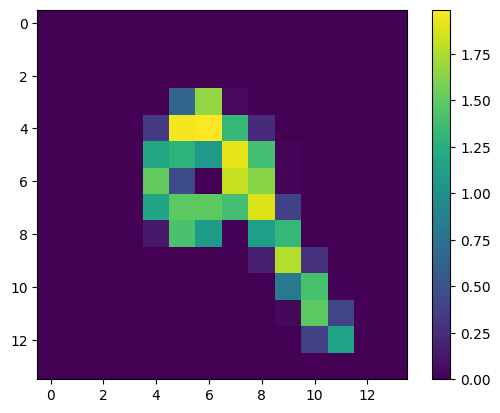

In [ ]:
plt.imshow(X_test[7])
plt.colorbar()
plt.show()

**Make Image pairs and SNN training**

In [ ]:
def make_pairs(x, y):
    """Creates a tuple containing image pairs with corresponding label.

    Arguments:
        x: List containing images, each index in this list corresponds to one image.
        y: List containing labels, each label with datatype of `int`.

    Returns:
        Tuple containing two numpy arrays as (pairs_of_samples, labels),
        where pairs_of_samples' shape is (2len(x), 2,n_features_dims) and
        labels are a binary array of shape (2len(x)).
    """

    num_classes = max(y) + 1
    digit_indices = [np.where(y == i)[0] for i in range(num_classes)]

    pairs = []
    labels = []

    for idx1 in range(len(x)):
        # add a matching example
        x1 = x[idx1]
        label1 = y[idx1]
        idx2 = random.choice(digit_indices[label1])
        x2 = x[idx2]

        pairs += [[x1, x2]]
        labels += [1]

        # add a non-matching example
        label2 = random.randint(0, num_classes - 1)
        while label2 == label1:
            label2 = random.randint(0, num_classes - 1)

        idx2 = random.choice(digit_indices[label2])
        x2 = x[idx2]

        pairs += [[x1, x2]]
        labels += [0]

    return np.array(pairs), np.array(labels).astype("float32")


# # make train pairs
pairs_train, labels_train = make_pairs(X_train, y_train)

# # make validation pairs
pairs_val, labels_val = make_pairs(X_valid, y_valid)

# # make test pairs
pairs_test, labels_test = make_pairs(X_test, y_test)

In [ ]:
#SNN architecture
input_shape= (14,14,1)     # for original (28,28,1)   #
left_input = Input(input_shape)
right_input = Input(input_shape)


model = keras.models.Sequential([
    keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=input_shape, padding='same',name='conv2d_1'),
    keras.layers.MaxPooling2D((2, 2), padding='same'),
    keras.layers.Conv2D(8, (3,3), activation='relu', padding='same',name='conv2d_2'),
    keras.layers.MaxPooling2D((2,2), padding='same'),
    keras.layers.Conv2D(8, (3,3), activation='relu', padding='same',name='conv2d_3'),
    keras.layers.MaxPooling2D((2,2), padding='same'),
    keras.layers.Flatten(),
  ])
encoded_l = model(left_input)
encoded_r = model(right_input)

subtracted = keras.layers.Lambda(euclidean_distance) ([encoded_l, encoded_r])
normal_layer = keras.layers.BatchNormalization()(subtracted)
prediction = Dense(1, activation='sigmoid')(normal_layer)
siamese_net = Model(inputs=[left_input, right_input], outputs=prediction)

optimizer= tf.keras.optimizers.Adam(learning_rate=0.01)
siamese_net.compile(loss=loss(margin=1), optimizer=optimizer, metrics=["accuracy"])   #loss='binary_crossentropy'loss(margin=1)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 8)        │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,904 (7.44 KB)

 Trainable params: 1,904 (7.44 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history= siamese_net.fit([pairs_train[:,0], pairs_train[:,1]], labels_train[:], validation_data=([pairs_val[:,0], pairs_val[:,1]], labels_val[:]),epochs= 10) #for fashion batch_size=128

Epoch 1/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 46s 13ms/step - accuracy: 0.9121 - loss: 0.0649 - val_accuracy: 0.9541 - val_loss: 0.0362
Epoch 2/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 42s 13ms/step - accuracy: 0.9432 - loss: 0.0432 - val_accuracy: 0.9567 - val_loss: 0.0333
Epoch 3/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - accuracy: 0.9498 - loss: 0.0384 - val_accuracy: 0.9653 - val_loss: 0.0272
Epoch 4/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - accuracy: 0.9542 - loss: 0.0355 - val_accuracy: 0.9642 - val_loss: 0.0281
Epoch 5/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 81s 13ms/step - accuracy: 0.9568 - loss: 0.0336 - val_accuracy: 0.9697 - val_loss: 0.0241
Epoch 6/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 43s 13ms/step - accuracy: 0.9589 - loss: 0.0320 - val_accuracy: 0.9707 - val_loss: 0.0235
Epoch 7/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 83s 13ms/step - accuracy: 0.9599 - loss: 0.0310 - val_accuracy: 0.9707 - val_loss: 0.0226
Epoch 8/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - accuracy: 0.9618 -

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


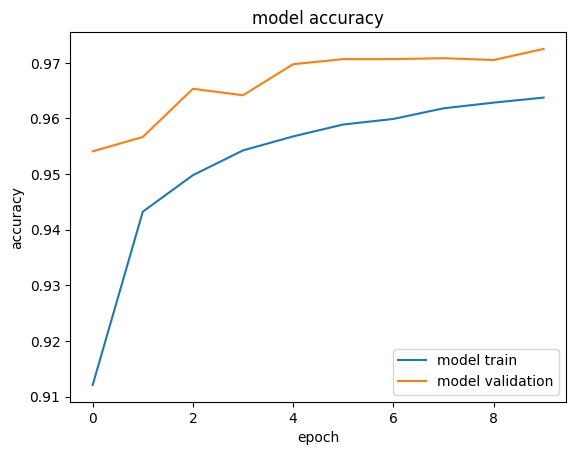

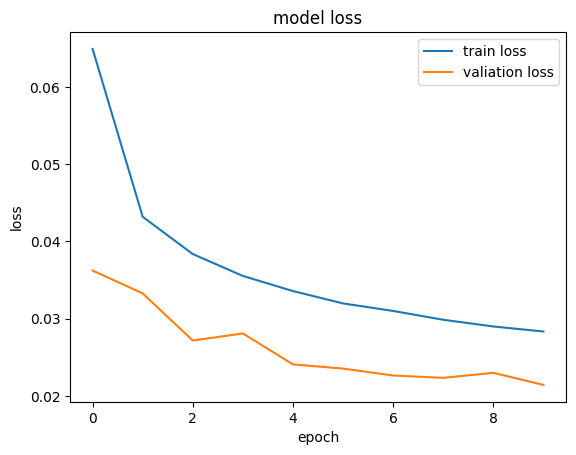

In [ ]:
#Plot the results
callbacks=[history]
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
#plt.ylim([0.50, 0.66])
plt.legend(['model train', 'model validation', ], loc='lower right')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train loss', 'valiation loss'], loc='upper right')
plt.show()

In [ ]:
# from sklearn.metrics import accuracy_score
accuracy =np.mean(history.history['accuracy'])
print(f'Training Accuracy: {accuracy}')

Training Accuracy: 0.9523351848125458


In [ ]:
# from sklearn.metrics import accuracy_score
loss =np.mean(history.history['loss'])
print(f'Training Loss: {loss}')

Training Loss: 0.036579270474612714


In [ ]:
accuracy_1 =np.mean(history.history['val_accuracy'])
print(f'Validation Accuracy: {accuracy_1}')

Validation Accuracy: 0.966516661643982


In [ ]:
# from sklearn.metrics import accuracy_score
loss_1 =np.mean(history.history['val_loss'])
print(f'Validation Loss: {loss_1}')

Validation Loss: 0.026181054674088954


**SNN Embeddings**

In [ ]:
# embeddings= model.predict(X_train)
embeddings= model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


**TSNE for SNN Embedding**

In [ ]:
X_embedded = TSNE(n_components=2,random_state=10).fit_transform(embeddings)

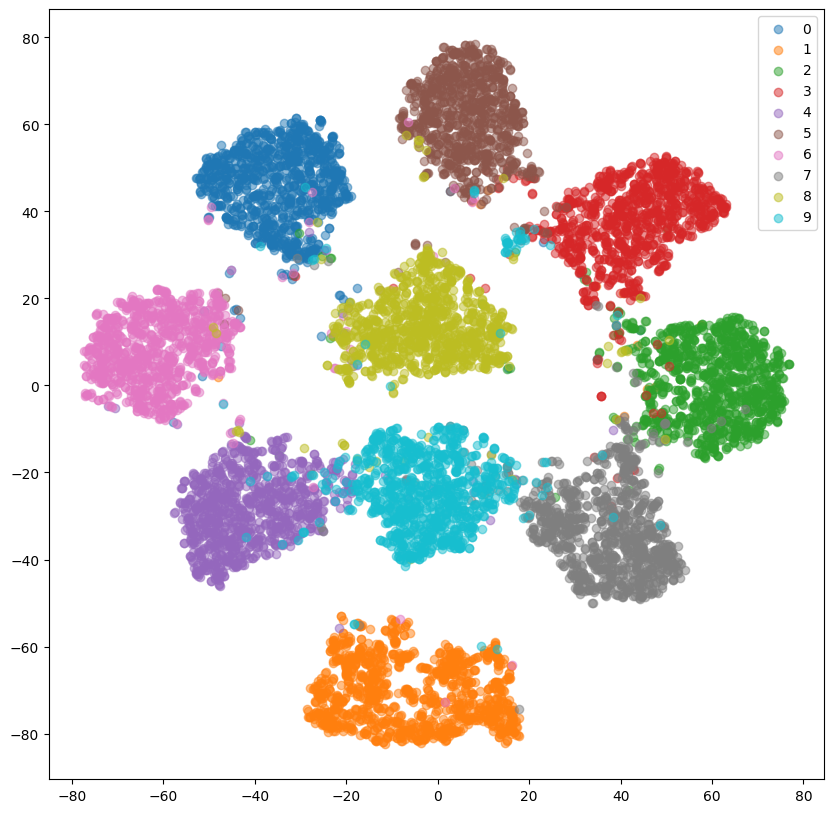

In [ ]:
mnist_classes = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
              '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
              '#bcbd22', '#17becf']

plt.figure(figsize=(10,10))
for i in range(10):
    inds = np.where(y_test==i)[0]
    plt.scatter(X_embedded[inds,0], X_embedded[inds,1], alpha=0.5, color=colors[i])
plt.legend(mnist_classes)

625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step


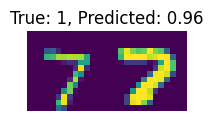

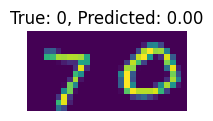

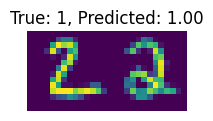

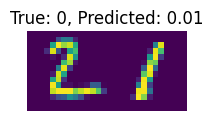

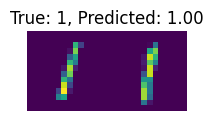

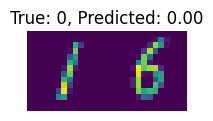

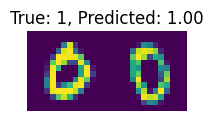

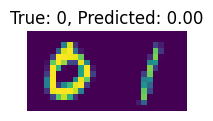

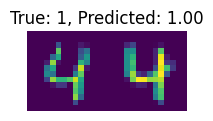

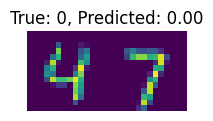

In [ ]:
# Make predictions
predictions = siamese_net.predict([pairs_test[:, 0], pairs_test[:, 1]])

# Plot true and predicted values for specific image pairs
for i in range(10):
    img1 = pairs_test[i, 0]
    # plt.imshow(img2)
    img2 = pairs_test[i, 1]
    true_label =labels_test[i]  # Access label from y_test
    predicted_similarity = predictions[i][0]  # Convert to scalar value
    plt.figure(figsize=(10,6))
    plt.subplot(5,2 , i+1)
    plt.imshow(np.concatenate((img1, img2), axis=1))
    plt.title(f'True: {int(true_label)}, Predicted: {predicted_similarity:.2f}')
    plt.axis('off')

plt.show()

In [ ]:
from sklearn.metrics import r2_score
# Calculate R²
r2 = r2_score(labels_test, predictions)

print("R²:", r2)

R²: 0.9032217860221863


In [ ]:
# Calculate MSE
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(labels_test, predictions)
print("MSE:", mse)

MSE: 0.024194559082388878


**IDWT(Inverse transformation for image reconstruction)**

In [ ]:
# recons_images_train = np.zeros((X_train.shape[0],28,28))
# recons_images_test = np.zeros((X_test.shape[0],28,28))
# recons_images_valid = np.zeros((X_valid.shape[0],28,28))

In [ ]:
# for indx in range(recons_images_train.shape[0]):
#     coef_train = pywt.wavedec2(X_train[indx],'haar',level=1)
#     recons_images_train[indx,:,:] = pywt.waverec2((coef_train[0],coef_train[1]),'haar')

In [ ]:
# for indx in range(recons_images_test.shape[0]):
#     coef_test = pywt.wavedec2(X_test[indx],'haar',level=1)
#     recons_images_test[indx,:,:] = pywt.waverec2((coef_test[0],coef_test[1]),'haar')

In [ ]:
# for indx in range(recons_images_valid.shape[0]):
#     coef_valid = pywt.wavedec2(X_valid[indx],'haar',level=1)
#     recons_images_valid[indx,:,:] = pywt.waverec2((coef_valid[0],coef_valid[1]),'haar')

In [ ]:
# X_train = recons_images_train
# X_test=recons_images_test
# X_valid=recons_images_valid

**SHAP Method on selected no.of image pairs**

In [ ]:
import shap

left_images = pairs_test[:,0]  # Load the left images data
right_images = pairs_test[:,1]  # Load the right images data

# Select 5 random image pairs
selected_indices = np.random.choice(len(left_images), 5, replace=False)
selected_left_images = left_images[selected_indices]
selected_right_images = right_images[selected_indices]

In [ ]:
# Create the SHAP explainer
explainer = shap.GradientExplainer(siamese_net, [selected_left_images, selected_right_images])

# Get the SHAP values for the input images
shap_values = explainer.shap_values([selected_left_images, selected_right_images])

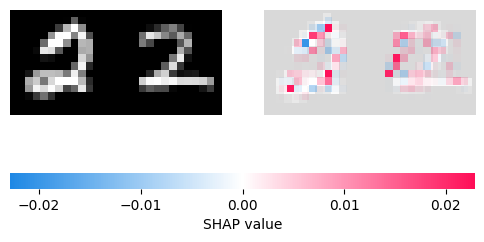

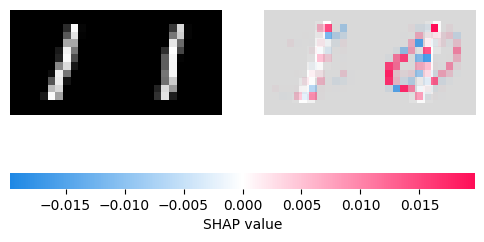

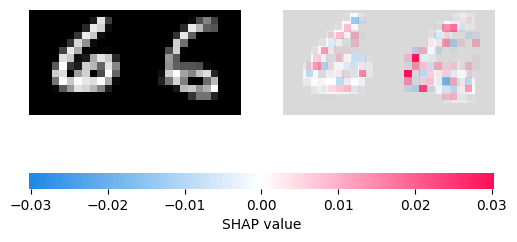

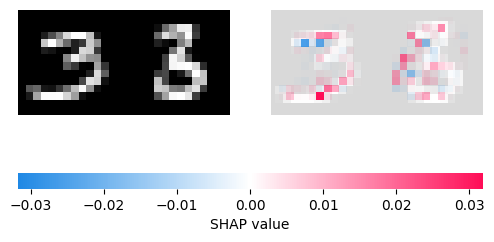

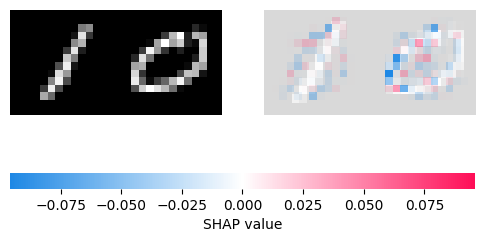

In [ ]:
# just SHAP explanation on selected number of image pairs
import numpy as np

for i in range(5):
    # Concatenate the images horizontally
    image_pair = np.concatenate((selected_left_images[i][:,:,0], selected_right_images[i][:,:,0]), axis=1)

    # Concatenate the SHAP values horizontally
    shap_pair = np.concatenate((shap_values[0][i,:,:,0], shap_values[1][i,:,:,0]), axis=1)

    # Plot the image pair and SHAP pair
    shap.plots.image(shap_pair, image_pair)

In [ ]:
# Create pair indices
pair_indices = np.arange(len(pairs_test))
print(pair_indices)
# Select same image pairs
selected_pairs = pairs_test[pair_indices]
selected_labels = labels_test[pair_indices]

# Make predictions
predictions = siamese_net.predict([selected_pairs[:, 0], selected_pairs[:, 1]])

[    0     1     2 ... 19997 19998 19999]
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step


In [ ]:
# importances =  np.abs(shap_values).sum(axis=0)
import numpy as np

# shap_values_min = np.min(shap_values)
# shap_values_max = np.max(shap_values)

# normalized_shap_values = (shap_values - shap_values_min) / (shap_values_max - shap_values_min)
sum_shap_values = np.sum(shap_values, axis=0)
normalized_shap_values =shap_values / np.linalg.norm(sum_shap_values)

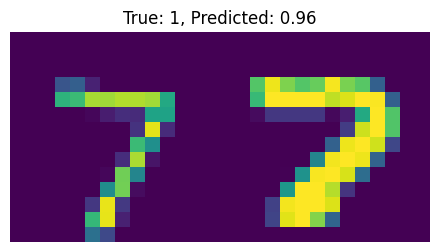

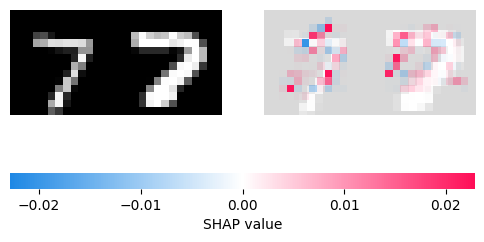

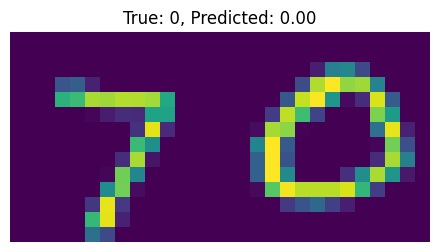

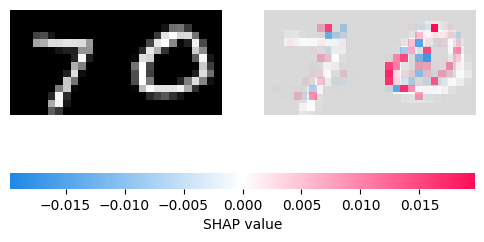

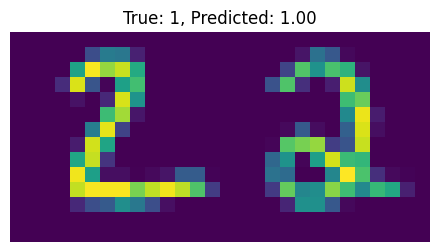

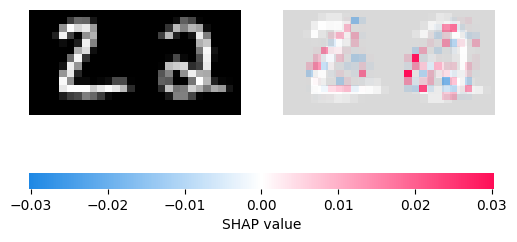

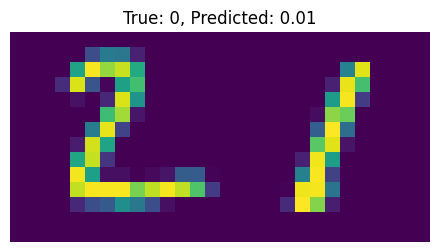

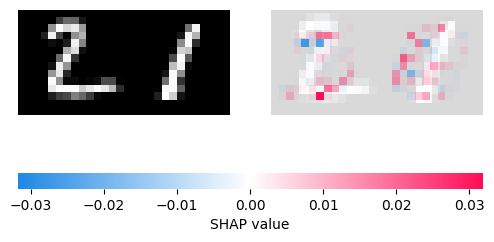

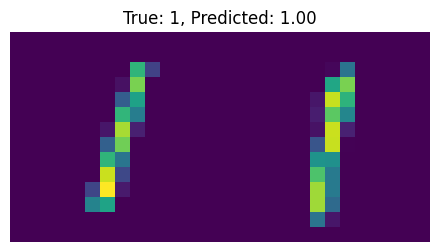

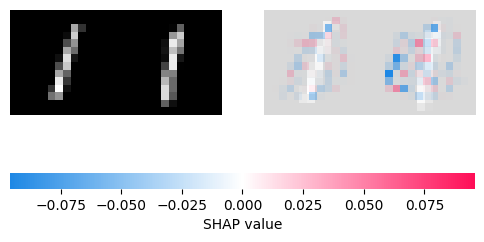

In [ ]:
for i in range(5):
    img1 = pairs_test[i, 0]
    img2 = pairs_test[i, 1]
    true_label = labels_test[i]
    predicted_similarity = predictions[i][0]

    # Get the SHAP values for the current pair
    # shap_value = shap_values[0][i]
    shap_value = np.squeeze(shap_values[0][i], axis=3)
    shap_value =np.concatenate((shap_values[0][i,:,:,0], shap_values[1][i,:,:,0]), axis=1)
    # concatenated_image = np.concatenate((img1[i][:,:,0], img2[i][:,:,0]), axis=1)

    # Concatenate the images along the width axis (axis=1)

    concatenated_image = np.concatenate((img1, img2), axis=1)

    # Plot the SHAP explanation
    plt.figure(figsize=(10, 6))
    plt.subplot(2, 1, 2)
    plt.imshow(concatenated_image)
    plt.title(f'True: {int(true_label)}, Predicted: {predicted_similarity:.2f}')
    plt.axis('off')

    plt.subplot(2, 1, 2)
    shap.plots.image(shap_value, concatenated_image)
plt.show()

**Architecture 2 for Class wise Precesion, Recall, F1 score**

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import precision_score

# Define the Siamese neural network architecture
input_shape = (28, 28, 1)  #(14,14,1)    #
left_input = Input(input_shape)
right_input = Input(input_shape)

conv1 = Conv2D(32, (3, 3), activation='relu')
max_pool1 = MaxPooling2D((2, 2))
flatten = Flatten()
dense1 = Dense(64, activation='relu')

left_output = conv1(left_input)
left_output = max_pool1(left_output)
left_output = flatten(left_output)
left_output = dense1(left_output)

right_output = conv1(right_input)
right_output = max_pool1(right_output)
right_output = flatten(right_output)
right_output = dense1(right_output)

merged = tf.keras.layers.Concatenate()([left_output, right_output])
output = Dense(10, activation='softmax')(merged)

model = Model(inputs=[left_input, right_input], outputs=output)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit([X_train, X_train], tf.keras.utils.to_categorical(y_train, 10), epochs=10, batch_size=128)

# Evaluate the model
y_pred = model.predict([X_test, X_test])
y_pred_class = np.argmax(y_pred, axis=1)
y_test_class = np.argmax(tf.keras.utils.to_categorical(y_test, 10), axis=1)

# Calculate precision for each class
precision = precision_score(y_test_class, y_pred_class, average=None)
print('Precision for each class:', precision)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 66s 151ms/step - accuracy: 0.9235 - loss: 0.2659
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 61s 144ms/step - accuracy: 0.9759 - loss: 0.0812
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 63s 98ms/step - accuracy: 0.9837 - loss: 0.0541
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 94ms/step - accuracy: 0.9879 - loss: 0.0408
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 99ms/step - accuracy: 0.9910 - loss: 0.0312
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 80s 95ms/step - accuracy: 0.9934 - loss: 0.0239
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 45s 105ms/step - accuracy: 0.9953 - loss: 0.0186
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 100ms/step - accuracy: 0.9965 - loss: 0.0144
Epoch 9/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 94ms/step - accuracy: 0.9971 - loss: 0.0121
Epoch 10/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 94ms/step - accuracy: 0.9973 - loss: 0.0101
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Precision for each class: [0.99176955 0.99122037 0.9588785  0.98128079 0.9

In [ ]:
recall = recall_score(y_test_class, y_pred_class, average=None)
print('recall for each class:', recall)

recall for each class: [0.98367347 0.99471366 0.99418605 0.98613861 0.98778004 0.99103139
 0.98329854 0.9688716  0.98459959 0.96927651]


In [ ]:
Fscore = f1_score(y_test_class, y_pred_class, average=None)
print('f1_score for each class:', Fscore)

f1_score for each class: [0.98770492 0.99296394 0.97621313 0.9837037  0.99131323 0.98550725
 0.98638743 0.98031496 0.98358974 0.9760479 ]


In [ ]:
accuracy = accuracy_score(y_test_class, y_pred_class)  #, average=None)
print('accuracy for each class:', accuracy)

accuracy for each class: 0.9844


<Axes: >

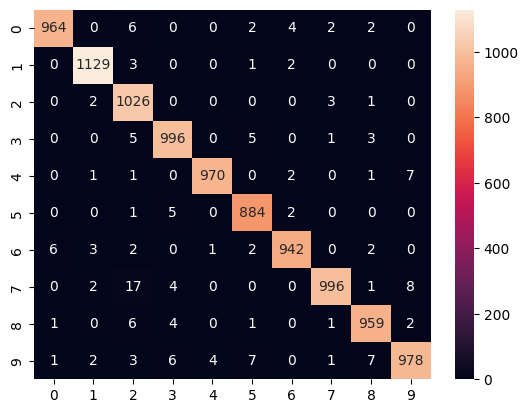

In [ ]:
cm = confusion_matrix(y_test_class, y_pred_class)
sns.heatmap(cm, annot=True, fmt="d")

**GRAD-CAM inspired SIMILAIRTITES AND PRESERVATION ERROR**

In [ ]:
import numpy as np
import tensorflow as tf

def get_gradcam(model, images, n=10000):

    G_all = []

    for img in images[:n]:

        # Add batch and channel dimensions
        if img.ndim == 2:
            x = img[np.newaxis, :, :, np.newaxis]
        else:
            x = img[np.newaxis, ...]

        x = tf.cast(x, tf.float32)

        with tf.GradientTape() as tape:

            # Conv1
            x1 = model.layers[0](x)

            # Pool1
            x2 = model.layers[1](x1)

            # Conv2
            x3 = model.layers[2](x2)

            # Pool2
            x4 = model.layers[3](x3)

            # Conv3 = target layer
            conv_output = model.layers[4](x4)

            # Pool3
            x5 = model.layers[5](conv_output)

            # Flatten
            embedding = model.layers[6](x5)

            # Representation score
            score = tf.reduce_sum(tf.square(embedding))

        # Gradient of representation score
        grads = tape.gradient(score, conv_output)

        # Global average pooling of gradients
        weights = tf.reduce_mean(grads, axis=(1, 2))

        # Weighted feature maps
        cam = tf.reduce_sum(
            conv_output * weights[:, None, None, :],
            axis=-1
        )

        # ReLU
        cam = tf.maximum(cam, 0)

        # Normalize
        cam = cam[0]
        cam = cam / (tf.reduce_max(cam) + 1e-8)

        G_all.append(cam.numpy())

    return np.array(G_all)

In [ ]:
G_original = get_gradcam(
    model,
    X_test,
    n=288     #47280   #8828   #8216   #10000
)

print(G_original.shape)

(288, 32, 32)


In [ ]:
G_reconstructed = get_gradcam(
    model,
    X_test_R,
    n=288   #47280 #8828   #8216   #17778  #10000
)

print(G_reconstructed.shape)

(288, 32, 32)


In [ ]:
gradcam_error = np.mean(
    np.abs(
        G_original -
        G_reconstructed   #_7x7
    ),
    axis=(1,2)
)

print("Grad-CAM error for each image:")
print(gradcam_error)

print(
    "Mean Grad-CAM error:",
    np.mean(gradcam_error)
)

Grad-CAM error for each image:
[0.02982731 0.02460373 0.01563182 0.02133845 0.0306531  0.02575164
 0.02185713 0.02387043 0.00955594 0.01959935 0.01330469 0.01386084
 0.02048668 0.01714072 0.01604142 0.01653082 0.00948052 0.01707505
 0.02380223 0.02452037 0.01741754 0.01403193 0.02531974 0.02981728
 0.01748605 0.02054213 0.02783194 0.03778359 0.01482769 0.02490607
 0.02212842 0.02092797 0.01586896 0.02049797 0.02256262 0.01976539
 0.01767125 0.01668055 0.02464601 0.02408746 0.011514   0.01518539
 0.01613703 0.0243571  0.01479489 0.01804911 0.01600823 0.02329571
 0.02150303 0.02892063 0.01632023 0.01608087 0.01641267 0.0271579
 0.02587831 0.02328338 0.02534391 0.0244429  0.0178922  0.01550745
 0.01712109 0.02473612 0.02481686 0.01901148 0.01557738 0.02351697
 0.02342375 0.01914665 0.01835848 0.0344684  0.02613725 0.02196497
 0.02749873 0.01618414 0.01850493 0.02241264 0.0219776  0.02459101
 0.01595514 0.02103917 0.02986888 0.01605144 0.01122623 0.02479409
 0.02308068 0.02558107 0.0168985

In [ ]:
gradcam_similarity = 1 - gradcam_error

print("Grad-CAM information preservation:")
print(gradcam_similarity)

print(
    "Mean:",
    np.mean(gradcam_similarity)
)

Grad-CAM information preservation:
[0.9701727  0.9753963  0.9843682  0.97866154 0.9693469  0.97424835
 0.97814286 0.9761296  0.99044406 0.9804007  0.9866953  0.9861392
 0.97951335 0.98285925 0.9839586  0.9834692  0.99051946 0.98292494
 0.9761978  0.9754796  0.98258245 0.98596805 0.97468024 0.9701827
 0.98251396 0.97945786 0.9721681  0.96221644 0.98517233 0.97509396
 0.9778716  0.97907203 0.98413104 0.979502   0.9774374  0.9802346
 0.9823288  0.98331946 0.975354   0.9759126  0.988486   0.98481464
 0.983863   0.9756429  0.9852051  0.9819509  0.98399174 0.9767043
 0.97849697 0.97107935 0.9836798  0.98391914 0.9835873  0.9728421
 0.9741217  0.97671664 0.9746561  0.9755571  0.9821078  0.98449254
 0.9828789  0.9752639  0.9751831  0.9809885  0.9844226  0.97648305
 0.97657627 0.9808533  0.98164153 0.9655316  0.97386277 0.97803503
 0.9725013  0.98381585 0.9814951  0.97758734 0.9780224  0.975409
 0.98404485 0.9789608  0.9701311  0.9839486  0.98877376 0.9752059
 0.9769193  0.97441894 0.9831015  0

In [ ]:
cosine_similarity = []

for i in range(288):   #10000

    g1 = G_original[i].flatten()
    g2 = G_reconstructed[i].flatten()   # G_reconstructed_7x7[i].flatten()

    similarity = np.dot(g1, g2) / (
        np.linalg.norm(g1) *
        np.linalg.norm(g2) + 1e-8
    )

    cosine_similarity.append(similarity)

cosine_similarity = np.array(cosine_similarity)

print("Grad-CAM cosine similarity:")
print(cosine_similarity)

print(
    "Mean:",
    np.mean(cosine_similarity)
)

Grad-CAM cosine similarity:
[0.9974754  0.99551094 0.99923086 0.9983877  0.9956424  0.995747
 0.9983035  0.998171   0.9995672  0.9982082  0.999227   0.99935913
 0.9984165  0.9985331  0.99892724 0.99864984 0.9995714  0.99844724
 0.99779874 0.99733937 0.99899167 0.99925715 0.997755   0.9952931
 0.9983844  0.998335   0.99547595 0.99951077 0.99903554 0.9980046
 0.99819475 0.9983745  0.99892104 0.99793345 0.9979244  0.99865144
 0.99864686 0.9986232  0.99672234 0.9970908  0.9995614  0.99910235
 0.99891233 0.9975789  0.9992475  0.9990789  0.9986696  0.9987277
 0.99865437 0.99685085 0.99892795 0.9990677  0.99882317 0.9960363
 0.9973202  0.99616545 0.99721164 0.9971973  0.9987472  0.99882084
 0.99858224 0.99748355 0.99604917 0.9984693  0.99893826 0.9982977
 0.99721086 0.9987171  0.9982476  0.99951816 0.99796844 0.99894947
 0.9983164  0.99906987 0.998139   0.99801683 0.9982397  0.9980208
 0.998916   0.9984081  0.99523854 0.99881816 0.99946207 0.9970416
 0.9989249  0.9984039  0.9985505  0.9977720

In [ ]:
import numpy as np

def importance_aware_error(G_original, G_reconstructed, epsilon=1e-8):
    """
    Importance-aware Representation Preservation Error.

    G_original      : Grad-CAM map of original image, shape (H, W)
    G_reconstructed : Grad-CAM map of reconstructed image, shape (H, W)

    Returns:
        error       : importance-weighted Grad-CAM error
        preservation: 1 - error
    """

    # --------------------------------------------------
    # 1. Normalize both Grad-CAM maps
    # --------------------------------------------------
    G_original = G_original / (np.max(G_original) + epsilon)
    G_reconstructed = G_reconstructed / (
        np.max(G_reconstructed) + epsilon
    )

    # --------------------------------------------------
    # 2. Importance weights from ORIGINAL Grad-CAM
    # --------------------------------------------------
    W_original = G_original / (
        np.sum(G_original) + epsilon
    )

    # --------------------------------------------------
    # 3. Absolute spatial difference
    # --------------------------------------------------
    spatial_difference = np.abs(
        G_original - G_reconstructed
    )

    # --------------------------------------------------
    # 4. Importance-aware error
    # --------------------------------------------------
    error = np.sum(
        W_original * spatial_difference
    )

    # --------------------------------------------------
    # 5. Preservation score
    # --------------------------------------------------
    preservation = 1.0 - error

    return error, preservation

In [ ]:
IW_error = []
IW_preservation = []

for n in range(len(G_original)):

    error, preservation = importance_aware_error(
        G_original[n],
        G_reconstructed[n]
    )

    IW_error.append(error)
    IW_preservation.append(preservation)

IW_error = np.array(IW_error)
IW_preservation = np.array(IW_preservation)

print("Mean Importance-Aware Error:",
      np.mean(IW_error))

print("Mean Importance-Aware Preservation:",
      np.mean(IW_preservation))

print("Std Importance-Aware Error:",
      np.std(IW_error, ddof=1))

print("Std Importance-Aware Preservation:",
      np.std(IW_preservation, ddof=1))

Mean Importance-Aware Error: 0.016664654
Mean Importance-Aware Preservation: 0.98333526
Std Importance-Aware Error: 0.0060334364
Std Importance-Aware Preservation: 0.0060334355


In [ ]:
G_o = G_original[0]
G_r = G_reconstructed[0]

G_o_norm = G_o / (G_o.max() + 1e-8)

W_o = G_o_norm / (G_o_norm.sum() + 1e-8)

print("Weight sum:", W_o.sum())
print("Weight range:", W_o.min(), W_o.max())

Weight sum: 0.99999994
Weight range: 0.0 0.0033439253


In [ ]:
np.unique(y_test)

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20])

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import sem, t

# --------------------------------------------------
# Get class labels
# --------------------------------------------------

# if y_test.ndim > 1:
#     y_labels = np.argmax(y_test, axis=1)
# else:
#     y_labels = y_test
y_labels = np.asarray(y_test).reshape(-1).astype(int)
# Make sure labels correspond to IW_errors
labels = y_labels[:len(IW_error)]

# --------------------------------------------------
# Class-wise Importance-Aware Error
# --------------------------------------------------

results = []

for digit in range(1, 21, 1):  #10

    values = np.asarray(IW_error)[labels == digit]

    N = len(values)

    mean_error = np.mean(values)
    std_error = np.std(values, ddof=1)

    # 95% confidence interval
    confidence = 0.95
    alpha = 1 - confidence

    if N > 1:
        standard_error = sem(values)
        t_critical = t.ppf(1 - alpha / 2, df=N - 1)

        CI_lower = mean_error - t_critical * standard_error
        CI_upper = mean_error + t_critical * standard_error
    else:
        CI_lower = np.nan
        CI_upper = np.nan

    results.append({
        "Digit": digit,
        "N": N,
        "Mean IW Error": mean_error,
        "Std": std_error,
        "95% CI Lower": CI_lower,
        "95% CI Upper": CI_upper
    })

# --------------------------------------------------
# DataFrame
# --------------------------------------------------

df_IW_class = pd.DataFrame(results)

print(df_IW_class.to_string(index=False))

 Digit  N  Mean IW Error      Std  95% CI Lower  95% CI Upper
     1 15       0.010736 0.002222      0.009506      0.011967
     2 16       0.013939 0.003942      0.011839      0.016040
     3 18       0.020179 0.003337      0.018519      0.021838
     4 17       0.013641 0.002404      0.012405      0.014877
     5 13       0.020630 0.004770      0.017748      0.023512
     6 11       0.022182 0.005966      0.018174      0.026190
     7 19       0.016672 0.003140      0.015158      0.018185
     8 13       0.018715 0.004221      0.016165      0.021266
     9 12       0.022106 0.001669      0.021045      0.023166
    10 14       0.023186 0.004031      0.020858      0.025513
    11 11       0.011433 0.002176      0.009971      0.012895
    12 16       0.013386 0.001853      0.012398      0.014373
    13 16       0.013418 0.002494      0.012089      0.014747
    14 17       0.013446 0.002290      0.012268      0.014624
    15 15       0.015426 0.012390      0.008565      0.022287
    16 1

In [ ]:
df_IW_class["Mean Preservation"] = (
    1 - df_IW_class["Mean IW Error"]
)

df_IW_class["Preservation CI Lower"] = (
    1 - df_IW_class["95% CI Upper"]
)

df_IW_class["Preservation CI Upper"] = (
    1 - df_IW_class["95% CI Lower"]
)

print(df_IW_class.to_string(index=False))

 Digit  N  Mean IW Error      Std  95% CI Lower  95% CI Upper  Mean Preservation  Preservation CI Lower  Preservation CI Upper
     1 15       0.010736 0.002222      0.009506      0.011967           0.989264               0.988033               0.990494
     2 16       0.013939 0.003942      0.011839      0.016040           0.986061               0.983960               0.988161
     3 18       0.020179 0.003337      0.018519      0.021838           0.979822               0.978162               0.981481
     4 17       0.013641 0.002404      0.012405      0.014877           0.986359               0.985123               0.987595
     5 13       0.020630 0.004770      0.017748      0.023512           0.979370               0.976488               0.982252
     6 11       0.022182 0.005966      0.018174      0.026190           0.977818               0.973810               0.981826
     7 19       0.016672 0.003140      0.015158      0.018185           0.983328               0.981815        

In [ ]:
import numpy as np
import pandas as pd

# labels_100 = y_test[:10000]
labels_100 = y_labels[:288]
results = []

for digit in range(1, 21, 1):

    values = cosine_similarity[labels_100 == digit]

    results.append([
        digit,
        len(values),
        np.mean(values),
        np.std(values),
        np.min(values),
        np.max(values)
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Digit",
        "N",
        "Mean",
        "Std",
        "Minimum",
        "Maximum"
    ]
)

print(results_df)

    Digit   N      Mean       Std   Minimum   Maximum
0       1  15  0.999278  0.000154  0.998919  0.999474
1       2  16  0.998631  0.000282  0.998139  0.999227
2       3  18  0.996128  0.001037  0.994658  0.998133
3       4  17  0.998643  0.000214  0.998376  0.999013
4       5  13  0.997636  0.000616  0.996851  0.998647
5       6  11  0.997499  0.001494  0.995590  0.999515
6       7  19  0.998420  0.000220  0.998089  0.998765
7       8  13  0.998222  0.000239  0.997924  0.998547
8       9  12  0.998148  0.000194  0.997848  0.998416
9      10  14  0.997779  0.000434  0.997280  0.998755
10     11  11  0.998846  0.000390  0.998248  0.999231
11     12  16  0.998852  0.000143  0.998576  0.999045
12     13  16  0.998985  0.000179  0.998648  0.999240
13     14  17  0.999212  0.000158  0.999036  0.999490
14     15  15  0.999561  0.000021  0.999511  0.999584
15     16  16  0.998638  0.000055  0.998548  0.998742
16     17  11  0.999569  0.000031  0.999522  0.999622
17     18  14  0.996843  0.0

In [ ]:
from scipy.stats import sem, t

for digit in range(1, 21, 1):

    values = cosine_similarity[labels_100 == digit]

    mean = np.mean(values)
    sd = np.std(values, ddof=1)
    n = len(values)

    ci = t.ppf(0.975, df=n-1) * sem(values)

    print(
        f"Digit {digit}: "
        f"{mean:.4f} ± {sd:.4f} "
        f"(95% CI: {mean-ci:.4f}–{mean+ci:.4f}), "
        f"N={n}"
    )

Digit 1: 0.9993 ± 0.0002 (95% CI: 0.9992–0.9994), N=15
Digit 2: 0.9986 ± 0.0003 (95% CI: 0.9985–0.9988), N=16
Digit 3: 0.9961 ± 0.0011 (95% CI: 0.9956–0.9967), N=18
Digit 4: 0.9986 ± 0.0002 (95% CI: 0.9985–0.9988), N=17
Digit 5: 0.9976 ± 0.0006 (95% CI: 0.9972–0.9980), N=13
Digit 6: 0.9975 ± 0.0016 (95% CI: 0.9964–0.9986), N=11
Digit 7: 0.9984 ± 0.0002 (95% CI: 0.9983–0.9985), N=19
Digit 8: 0.9982 ± 0.0002 (95% CI: 0.9981–0.9984), N=13
Digit 9: 0.9981 ± 0.0002 (95% CI: 0.9980–0.9983), N=12
Digit 10: 0.9978 ± 0.0005 (95% CI: 0.9975–0.9980), N=14
Digit 11: 0.9988 ± 0.0004 (95% CI: 0.9986–0.9991), N=11
Digit 12: 0.9989 ± 0.0001 (95% CI: 0.9988–0.9989), N=16
Digit 13: 0.9990 ± 0.0002 (95% CI: 0.9989–0.9991), N=16
Digit 14: 0.9992 ± 0.0002 (95% CI: 0.9991–0.9993), N=17
Digit 15: 0.9996 ± 0.0000 (95% CI: 0.9995–0.9996), N=15
Digit 16: 0.9986 ± 0.0001 (95% CI: 0.9986–0.9987), N=16
Digit 17: 0.9996 ± 0.0000 (95% CI: 0.9995–0.9996), N=11
Digit 18: 0.9968 ± 0.0007 (95% CI: 0.9965–0.9972), N=14
D

In [ ]:
overall_mean = np.mean(cosine_similarity)

for digit in range(1, 21, 1):

    values = cosine_similarity[labels_100 == digit]
    class_mean = np.mean(values)

    print(
        f"Digit {digit}: "
        f"Mean = {class_mean:.4f}, "
        f"Deviation = {class_mean-overall_mean:+.4f}"
    )

Digit 1: Mean = 0.9993, Deviation = +0.0010
Digit 2: Mean = 0.9986, Deviation = +0.0004
Digit 3: Mean = 0.9961, Deviation = -0.0021
Digit 4: Mean = 0.9986, Deviation = +0.0004
Digit 5: Mean = 0.9976, Deviation = -0.0006
Digit 6: Mean = 0.9975, Deviation = -0.0008
Digit 7: Mean = 0.9984, Deviation = +0.0002
Digit 8: Mean = 0.9982, Deviation = -0.0000
Digit 9: Mean = 0.9981, Deviation = -0.0001
Digit 10: Mean = 0.9978, Deviation = -0.0005
Digit 11: Mean = 0.9988, Deviation = +0.0006
Digit 12: Mean = 0.9989, Deviation = +0.0006
Digit 13: Mean = 0.9990, Deviation = +0.0007
Digit 14: Mean = 0.9992, Deviation = +0.0010
Digit 15: Mean = 0.9996, Deviation = +0.0013
Digit 16: Mean = 0.9986, Deviation = +0.0004
Digit 17: Mean = 0.9996, Deviation = +0.0013
Digit 18: Mean = 0.9968, Deviation = -0.0014
Digit 19: Mean = 0.9964, Deviation = -0.0019
Digit 20: Mean = 0.9974, Deviation = -0.0008


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import sem, t

# ============================================================
# INPUTS
# ============================================================
# gradcam_cosine : array of Grad-CAM cosine similarities
# IW_errors      : array of Importance-Weighted Representation Errors
# y_test         : MNIST labels (one-hot or integer labels)

gradcam_cosine = np.asarray(cosine_similarity)
IW_errors = np.asarray(IW_error)

# Convert one-hot labels to class numbers if necessary
if y_test.ndim > 1:
    y_labels = np.argmax(y_test, axis=1)
else:
    y_labels = np.asarray(y_test)
# y_labels = np.asarray(y_test).reshape(-1).astype(int)

# Make sure all arrays have the same length
N_total = min(
    len(gradcam_cosine),
    len(IW_errors),
    len(y_labels)
)

gradcam_cosine = gradcam_cosine[:N_total]
IW_errors = IW_errors[:N_total]
y_labels = y_labels[:N_total]


# ============================================================
# FUNCTION FOR 95% CI
# ============================================================
def confidence_interval(values, confidence=0.95):
    values = np.asarray(values)
    n = len(values)

    mean = np.mean(values)

    if n <= 1:
        return mean, np.nan, np.nan

    standard_error = sem(values)

    alpha = 1 - confidence
    t_critical = t.ppf(
        1 - alpha / 2,
        df=n - 1
    )

    margin = t_critical * standard_error

    lower = mean - margin
    upper = mean + margin

    return mean, lower, upper


# ============================================================
# CLASS-WISE RESULTS
# ============================================================
results = []

for digit in range(1, 21, 1):

    # Select images belonging to this digit
    mask = (y_labels == digit)

    cosine_values = gradcam_cosine[mask]
    iw_values = IW_errors[mask]

    N = len(cosine_values)

    # --------------------------------------------------------
    # Grad-CAM cosine similarity
    # --------------------------------------------------------
    cosine_mean, cosine_lower, cosine_upper = confidence_interval(
        cosine_values
    )

    # --------------------------------------------------------
    # Importance-weighted error
    # --------------------------------------------------------
    iw_mean, iw_lower, iw_upper = confidence_interval(
        iw_values
    )

    # --------------------------------------------------------
    # Preservation
    # Preservation = 1 - IW Error
    # --------------------------------------------------------
    preservation_mean = 1 - iw_mean

    # CI reverses when subtracting from 1
    preservation_lower = 1 - iw_upper
    preservation_upper = 1 - iw_lower

    # Format CIs
    cosine_ci = f"{cosine_lower:.4f} – {cosine_upper:.4f}"

    iw_ci = f"{iw_lower:.4f} – {iw_upper:.4f}"

    preservation_ci = (
        f"{preservation_lower:.4f} – {preservation_upper:.4f}"
    )

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------
    results.append({
        "Class": digit,
        "N": N,
        "Grad-CAM Similarity": cosine_mean,
        "95% CI": cosine_ci,
        "Mean IW Error": iw_mean,
        "95% Error CI": iw_ci,
        "Mean Preservation": preservation_mean,
        "95% Preservation CI": preservation_ci
    })


# ============================================================
# CREATE TABLE
# ============================================================
df_results = pd.DataFrame(results)


# ============================================================
# ROUND NUMERICAL VALUES
# ============================================================
df_results["Grad-CAM Similarity"] = (
    df_results["Grad-CAM Similarity"].round(4)
)

df_results["Mean IW Error"] = (
    df_results["Mean IW Error"].round(4)
)

df_results["Mean Preservation"] = (
    df_results["Mean Preservation"].round(4)
)


# ============================================================
# DISPLAY TABLE
# ============================================================
print(df_results.to_string(index=False))


# ============================================================
# SAVE TABLE
# ============================================================
df_results.to_csv(
    "MNIST_classwise_representation_preservation.csv",
    index=False
)

df_results.to_excel(
    "MNIST_classwise_representation_preservation.xlsx",
    index=False
)

 Class  N  Grad-CAM Similarity          95% CI  Mean IW Error    95% Error CI  Mean Preservation 95% Preservation CI
     1 15               0.9993 0.9992 – 0.9994         0.0107 0.0095 – 0.0120             0.9893     0.9880 – 0.9905
     2 16               0.9986 0.9985 – 0.9988         0.0139 0.0118 – 0.0160             0.9861     0.9840 – 0.9882
     3 18               0.9961 0.9956 – 0.9967         0.0202 0.0185 – 0.0218             0.9798     0.9782 – 0.9815
     4 17               0.9986 0.9985 – 0.9988         0.0136 0.0124 – 0.0149             0.9864     0.9851 – 0.9876
     5 13               0.9976 0.9972 – 0.9980         0.0206 0.0177 – 0.0235             0.9794     0.9765 – 0.9823
     6 11               0.9975 0.9964 – 0.9986         0.0222 0.0182 – 0.0262             0.9778     0.9738 – 0.9818
     7 19               0.9984 0.9983 – 0.9985         0.0167 0.0152 – 0.0182             0.9833     0.9818 – 0.9848
     8 13               0.9982 0.9981 – 0.9984         0.0187 0.